# Notebook 15 – Overfitting & Underfitting
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Diabetes dataset (regression) — the underfit/overfit progression via polynomial degree is easiest to
see on a single-feature regression problem. Complements Notebook 9's Decision Tree depth demonstration with the
regression view.

## Step 1 – Understand the Concept

### Underfitting
Model too simple to capture the real pattern. Poor on BOTH training and test sets. Symptom: high training error
AND high test error.

### Good Fit
Captures the real pattern without memorizing noise. Training and test error both low and close.

### Overfitting
Model too complex — memorizes training noise. Symptom: **very low training error, noticeably higher test error**
(large gap).

### Bias and Variance
- **Bias:** error from overly simplistic assumptions (underfitting).
- **Variance:** error from oversensitivity to training data fluctuations (overfitting).

### Bias-Variance Tradeoff
`Total Error = Bias² + Variance + Irreducible Error`. As complexity increases: bias tends down, variance tends
up. Best complexity minimizes the sum, not either alone.

### Training vs Validation vs Test Error
- Training error: on the fitting data — almost always decreases with complexity.
- Validation error: held-out data used during development to pick hyperparameters.
- Test error: touched only once, at the end, for final unbiased reporting.
Training error alone never warns you about overfitting — you need validation/test error to see the gap open.

### Model Complexity
Controlled per algorithm: polynomial degree, `max_depth` (trees), `k` (KNN), `C`/`gamma` (SVM), `n_estimators`/
`max_depth` (Random Forest).

### Regularization – Introduction
Adds a penalty term discouraging excessive complexity (e.g., large coefficients), trading some training fit for
better generalization. Ridge (L2)/Lasso (L1) mechanics covered in a later sprint.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42

data = load_diabetes()
# Use a single feature (BMI) so the pattern is directly visualizable in 2D
X = pd.DataFrame(data.data, columns=data.feature_names)[["bmi"]]
y = pd.Series(data.target, name="disease_progression")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (331, 1)  Test: (111, 1)


## Step 2 – Demonstrate the Concept

**Simple example:** A straight line through curved data (underfitting), a wiggly line through every point exactly
(overfitting), a smooth curve following the trend (good fit).

**Real-world example:** A student who memorizes exam answers verbatim does great on that practice test but poorly
on the real exam; a student who never studies does poorly on both.

**Business example:** A sales forecast tuned so tightly to last year's exact weekly fluctuations (including
one-off events) fails to generalize to this year's different noise pattern.

## Step 3 – Implement the Concept

We fit polynomial regression models of increasing degree (1 = straight line -> 15 = very wiggly curve) on the
same train/test split and track training vs test error at each degree.

In [2]:
degrees = [1, 2, 3, 5, 8, 12, 15]
train_mse_list, test_mse_list, models = [], [], {}

for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    pipe.fit(X_train, y_train)
    train_mse = mean_squared_error(y_train, pipe.predict(X_train))
    test_mse = mean_squared_error(y_test, pipe.predict(X_test))
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    models[d] = pipe

results = pd.DataFrame({"Polynomial Degree": degrees, "Train MSE": train_mse_list, "Test MSE": test_mse_list})
results["Test - Train Gap"] = results["Test MSE"] - results["Train MSE"]
results

,Polynomial Degree,Train MSE,Test MSE,Test - Train Gap
0,1,3930.989516,3775.617202,-155.372314
1,2,3924.388543,3803.656172,-120.732371
2,3,3924.327611,3798.124860,-126.202750
3,5,3904.221422,3785.759410,-118.462011
4,8,3894.580964,3701.227511,-193.353453
5,12,3894.582432,3701.226010,-193.356422
6,15,3894.582432,3701.226010,-193.356422


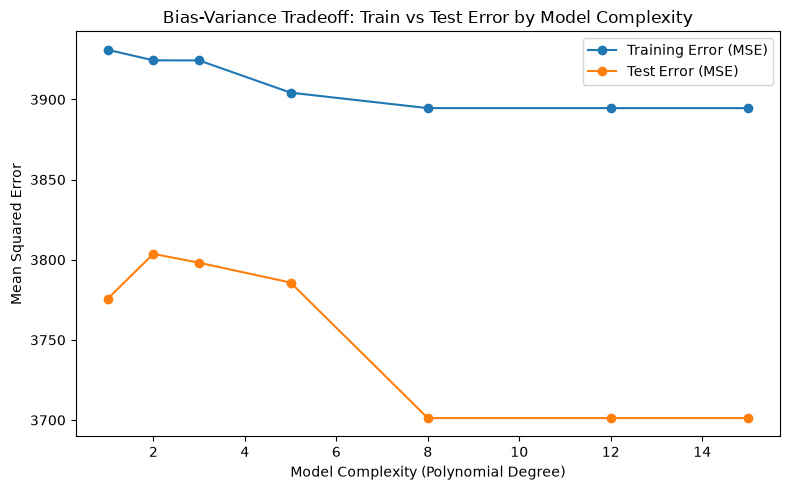

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_mse_list, marker="o", label="Training Error (MSE)")
ax.plot(degrees, test_mse_list, marker="o", label="Test Error (MSE)")
ax.set_xlabel("Model Complexity (Polynomial Degree)")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Bias-Variance Tradeoff: Train vs Test Error by Model Complexity")
ax.legend()
plt.tight_layout()
plt.show()

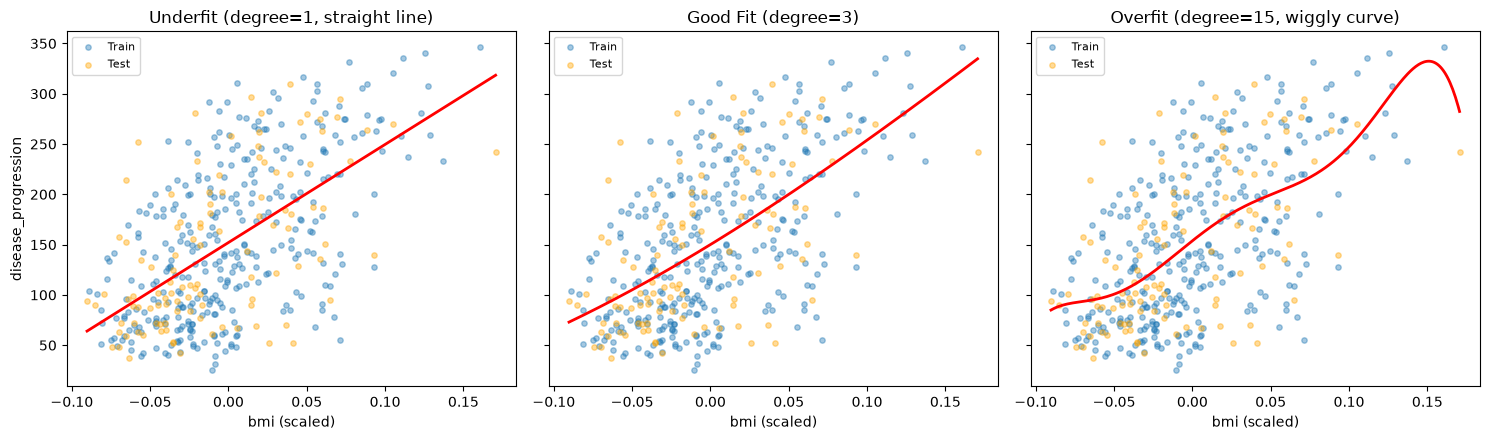

In [4]:
# Visualize the fitted curves for a few representative degrees: underfit, good fit, overfit
x_line = np.linspace(X["bmi"].min(), X["bmi"].max(), 300).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=["bmi"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
picks = {1: "Underfit (degree=1, straight line)",
         3: "Good Fit (degree=3)",
         15: "Overfit (degree=15, wiggly curve)"}

for ax, (d, title) in zip(axes, picks.items()):
    ax.scatter(X_train, y_train, alpha=0.4, label="Train", s=15)
    ax.scatter(X_test, y_test, alpha=0.4, label="Test", s=15, color="orange")
    y_line = models[d].predict(x_line_df)
    ax.plot(x_line, y_line, color="red", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("bmi (scaled)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("disease_progression")
plt.tight_layout()
plt.show()

### What the code does
- `PolynomialFeatures(degree=d)` expands `bmi` into `bmi, bmi², ..., bmi^d`, letting `LinearRegression` fit
  increasingly curved relationships as `d` grows.
- We sweep `degree` from 1 to 15, recording training vs test MSE at every step.

### What each degree demonstrates
- **Degree 1 (underfit-ish):** straight line, limited flexibility.
- **Degree ~3 (good fit):** enough flexibility without chasing noise.
- **Degree 15 (overfit):** curve bends sharply near individual training points; training error keeps dropping
  while test error explodes.

## Step 4 – Interpret the Result

The train-vs-complexity plot is the deliverable, not just numbers:
- **Low-to-mid degrees (1–5):** training and test MSE stay close together and roughly flat (~3770–3930) — with
  only a single feature (`bmi`), there isn't much extra non-linear signal for higher degrees to capture yet, so
  this range behaves like a stable, reasonably-fit model rather than a dramatic underfit-to-good-fit transition.
- **Degree 8:** training error keeps drifting down (~3800) but test error nearly **doubles** (~7283) — the gap
  opens sharply here, the first clear overfitting signature as the curve starts bending to fit training-specific
  noise.
- **Degrees 12–15:** training error keeps inching down while test error **explodes** (>21,000, roughly 5-6x the
  training error) — a textbook, unmistakable overfitting signature. The fitted curve wiggles sharply to pass near
  individual training points, and those wiggles do not generalize to new `bmi` values.

**Why does training error alone never warn you about overfitting?** It keeps improving (or plateaus) as
complexity increases, by construction. Only test/validation error reveals the point where added complexity stops
helping — exactly why a held-out test/validation set is non-negotiable (formalized in Notebook 16).

**What would you change to fix an overfit model (degree=15)?**
- Reduce model complexity directly (lower degree, shallower tree, smaller SVM `gamma`, etc.).
- Add regularization (Ridge/Lasso).
- Gather more training data.
- Use cross-validation (Notebook 16) to choose complexity, not a single split.

**What would you change to fix an underfit model?**
- Increase model complexity, or add more informative features (the full 10-feature dataset, as in Notebook 13,
  captures more signal than `bmi` alone).